# Sprint 8 - Proyecto

# Paso 4. Análisis exploratorio de datos (Python)

#### Importaciones

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

#### Se cargan los data frames que se requieren para la primera parte

In [2]:
df_companies = pd.read_csv(r"C:\\Users\\sasor\\Desktop\\Tripleten\\Sprint 8\\proyecto\\moved_project_sql_result_01.csv")

df_locations = pd.read_csv(r"C:\\Users\\sasor\\Desktop\\Tripleten\\Sprint 8\\proyecto\\moved_project_sql_result_04.csv")

### Verificacion de los datos

A continuacion vamos a, primero que nada, verificar que se hayan cargado los datos correctamente

In [3]:
"""esto nos permite revisar que se haya cargado correctamente"""
print(df_companies.head())

                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                 Medallion Leasin         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299


In [4]:
print(df_locations.head())

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000


### Verificamos los tipos de datos

In [5]:
"""aqui se verifica el tipo de datos de cada una"""
print(df_companies.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None


In [6]:
print(df_locations.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


In [7]:
print(df_companies.dtypes)


company_name    object
trips_amount     int64
dtype: object


In [8]:
print(df_locations.dtypes)

dropoff_location_name     object
average_trips            float64
dtype: object


con esto se comprueba que los datos de nombres pertencen a string, y los int y float corresponden a su naturaleza en ambos data frames. no se requiere limpieza adicional

### # identificar los 10 principales barrios en términos de finalización del recorrido
se hace una agrupacion por la columna average_trips, poniendo los 10 mas altos que pide la instruccion


In [9]:
top10_locations = df_locations.sort_values(by="average_trips", ascending=False).head(10)
print(top10_locations)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


### hacer gráficos: empresas de taxis y número de viajes, los 10 barrios principales por número de finalizaciones

### Empresas de taxis y num de viajes

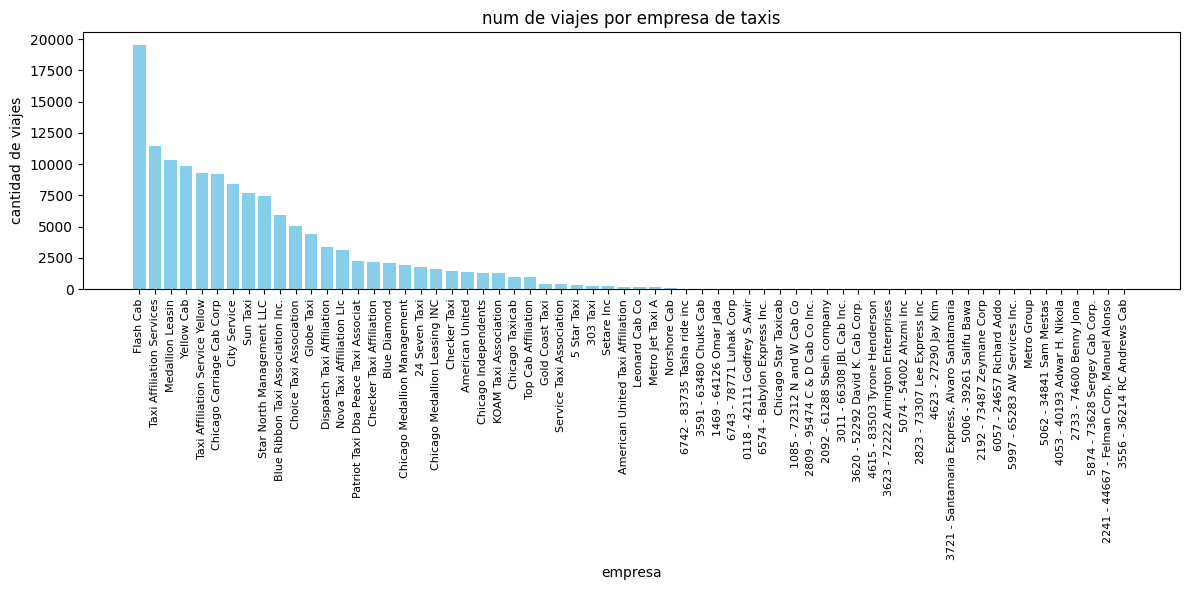

In [ ]:
plt.figure(figsize=(12,6))
plt.bar(df_companies["company_name"], df_companies["trips_amount"], color="skyblue")
plt.xticks(rotation=90, fontsize=8)
plt.title("num de viajes por empresa de taxis")
plt.xlabel("empresa")
plt.ylabel("cantidad de viajes")
plt.tight_layout()
plt.show()

### Grafico de top 10 barrios por finalizacion de viajes

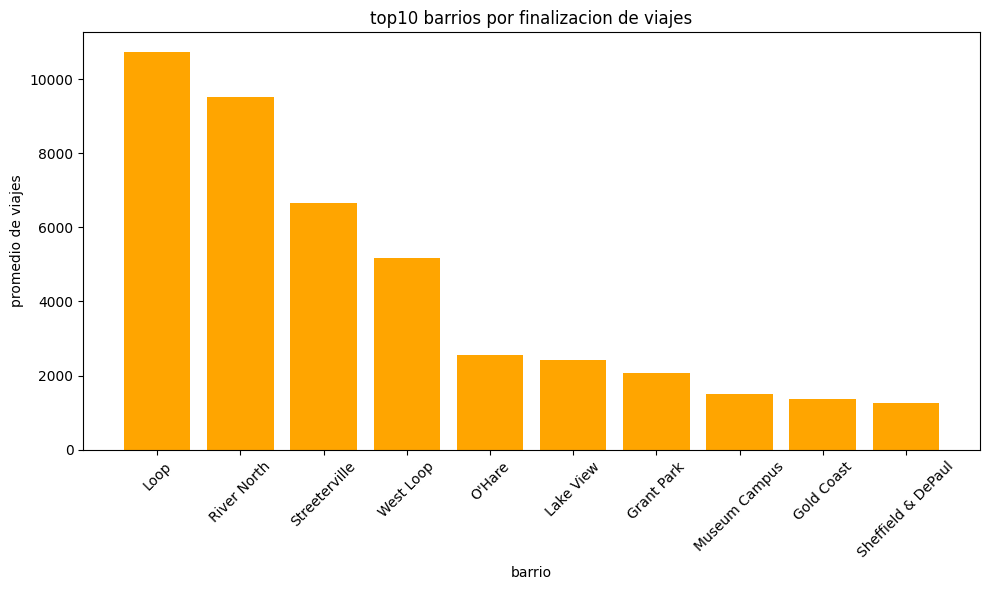

In [ ]:
top10_locations = df_locations.sort_values(by="average_trips", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10_locations["dropoff_location_name"], top10_locations["average_trips"], color="orange")
plt.xticks(rotation=45)
plt.title("top10 barrios por finalizacion de viajes")
plt.xlabel("barrio")
plt.ylabel("promedio de viajes")
plt.tight_layout()
plt.show()

## Conclusiones de las graficas presentadas

En el primer grafico (num de viajes por empresa y taxis), vemos que flash cab lidera en cantidad de viajes superando a cualquier otra por minimo, casi el doble de rendimiento. SIendo solo el top 5 que se le acerca, las demas son demasiado menores las cantidades en viajes. Muy problablemente esto se deba a que tenemos bastantes empresas y es normal ver la distribucion de viajes tan distinta, sin embargo que exista una de tal nivel quiere decir que hay mas contexto que nos hace falta, muy probablemente sea la empresa mas grande en general, que permita mas inversion en activo para seguir con las operaciones con mas frecuencia que la competencia."""

"""en el segundo grafico(top10 barrios por finalizacion de viajes) vemos que Loop y rivernorth estan casi a la par, siendo los mas populares y de ahi el top3 es streetville, siento este el top que opaca a las demas destinaciones, quizas sea el atractivo turistico y ademas el tamaño del lugar, ya que lugares con mas espacio, suele tener distintos puntos para aprovechar la visita de las personas como por ejemplo: recuerdos o souvenirs, comida, atracciones, etc.

# # Paso 5. Prueba de hipótesis (Python)

- Hipótesis nula (H₀):La duración promedio de los viajes del Loop a O’Hare los sábados no cambia entre condiciones de clima bueno y malo.

- Hipótesis alternativa (H₁): La duración promedio de los viajes del Loop a O’Hare los sábados sí cambia cuando el clima es malo (lluvia o tormenta).

- Decide por tu cuenta dónde establecer el nivel de significación (alfa).
se decide el 0.02 ya que el 2% es mas reducido el margen, y para probar los resultados si acepto solo 2% de probabilidad de rechazar la h nula

In [12]:
alpha = 0.02

### Se carga el dataframe que se pide para esta parte

In [13]:
df_weather_trips = pd.read_csv(r"C:\\Users\\sasor\\Desktop\\Tripleten\\Sprint 8\\proyecto\\moved_project_sql_result_07.csv")

"""revisamos sus tipos"""
print(df_weather_trips.dtypes)

start_ts               object
weather_conditions     object
duration_seconds      float64
dtype: object


### la fecha esta en el tipo de datos incorrecto, por lo que se corrige


In [14]:
df_weather_trips["start_ts"] = pd.to_datetime(df_weather_trips["start_ts"])
print(df_weather_trips.dtypes) #para verificar que el cambio se haya hecho

start_ts              datetime64[ns]
weather_conditions            object
duration_seconds             float64
dtype: object


In [15]:
"""separo primero entre Good or Bad clima para iniciar y ver en un futuro si el clima afecta a la duracion del vuelo"""
good_weather = df_weather_trips[df_weather_trips["weather_conditions"]=="Good"]["duration_seconds"]
bad_weather = df_weather_trips[df_weather_trips["weather_conditions"]=="Bad"]["duration_seconds"]


"""se comprueba el promedio de cada categoria"""
print("promedio clima bueno:", good_weather.mean())
print("promedio clima malo:", bad_weather.mean())

promedio clima bueno: 1999.6756756756756
promedio clima malo: 2427.2055555555557


# Prueba t


In [16]:
t_stat, p_value = stats.ttest_ind(good_weather, bad_weather, equal_var=False)

print("t stat:", t_stat)
print("p-value:", p_value)

if p_value < alpha:
    print("se rechaza H0: la duracion promedio cambia en sabados lluviosos")
else:
    print("no se rechaza H0: no hay evidencia suficiente de la diferencia")


t stat: -7.186034288068629
p-value: 6.738994326108734e-12
se rechaza H0: la duracion promedio cambia en sabados lluviosos


# Conclusiones

t de student nos sirve para las muestras independientes. en este caso queremos analizar la variable "duration_seconds" ya que es cuantitativa y continua lo cual nos facilita su analisis y manipulacion.

en este caso decidi separar los dos grupos en clima bueno y malo, ya que es una de las unicas opciones que hay para diferencias alguno de los viajes que venia.

en este caso vamos a evaluar si este cambio de temperatura buena o mala, tiene un impacto directo en la duracion del viaje.

los resultaods muestran que:
- la hipotesis nula plantea que si hay relacion en los dias con mal clima y su duracion de viaje lo cual es totalmente entendible. En los dias lluviosos suele haber turbulencias y para evitarlo se toman rutas alternas. Generalmente estas cosas se calculan desde antes por lo que las aproximaciones deben de concordar con estas conclusiones.